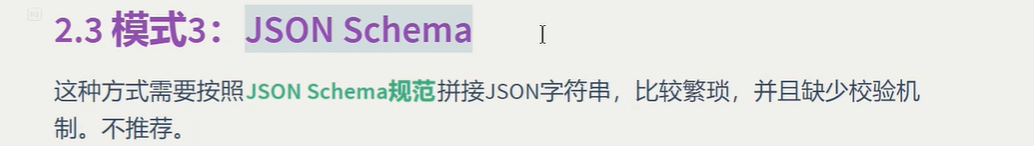

## 举例1

In [1]:
from langchain_openai import ChatOpenAI
from pydantic_core.core_schema import json_schema
from typing_extensions import TypedDict, Annotated
from typing import List
# 创建模型实例
model = ChatOpenAI(
    model="mistral-nemo:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

json_schema = {
    "title": "Movie",
    "description":"A Movie with detail",
    "type": "object",
    "properties": {
        "title": {
            "type": "string",
            "description":" The title of the movie",
        },
        "year": {
            "type": "integer",
            "description":" The year of the movie released",
        },
        "director": {
            "type": "string",
            "description":" The director of the movie",
        },
        "rating": {
            "type": "number",
            "description":" The rating of the movie",
        },
    },
    "required": ["title", "year", "director", "rating"],
}

s_model = model.with_structured_output(json_schema,method="json_schema")
result = s_model.invoke("给我电影盗梦空间的信息")
print(result)

{'title': 'Inception (2010)', 'year': 2010, 'director': 'Christopher Nolan', 'rating': 8.9}


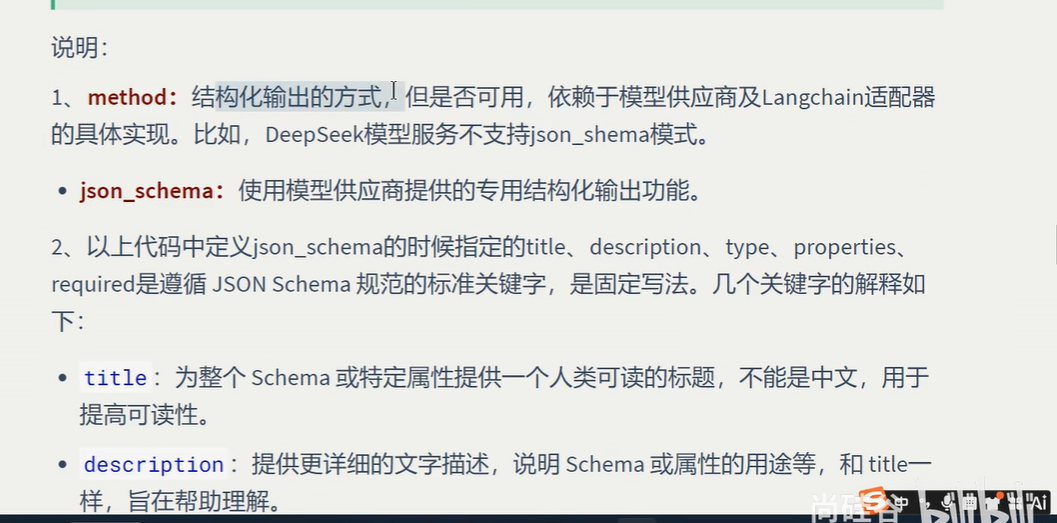

### 举例2

In [2]:
from langchain_openai import ChatOpenAI
from pydantic_core.core_schema import json_schema
from typing_extensions import TypedDict, Annotated
from typing import List
# 创建模型实例
model = ChatOpenAI(
    model="mistral-nemo:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

project_schema = {
    "title": "MovieInfo",
    "description":"包含电影标题，上映年份，导演，演员和评分的电影对象",
    "type": "object",
    "properties": {
        "title": {
            "type": "string",
            "description":"电影标题",
        },
        "year": {
            "type": "integer",
            "description":"上映年份",
        },
        "director": {
            "type": "string",
            "description":" 导演",
        },
        "cast": {
           "type": "array",
           "description":"演员列表",
            "items":{
                "type": "object",
                "properties":{
                    "name":{"type": "string","description":"演员姓名",},
                    "role":{"type": "string","description":"角色",},
                },
                "required":["name","role"],
            }
        }
        ,
        "rating": {
            "type": "number",
            "description":"评分(10分制)",
        },
    },
    "required": ["title", "year", "director", "rating"],
}

s_model = model.with_structured_output(project_schema,method="json_schema")
result = s_model.invoke("生成一个关于《星际穿越》的电影信息，包含导演，演员，评分")
print(result)

{'title': '《星际穿越》', 'year': 2014, 'director': '克里斯托弗·诺兰', 'rating': 9.0, 'cast': [{'name': '马修·麦康纳', 'role': '该片男主角库珀'}, {'name': '安妮·海瑟薇', 'role': '库珀的女儿默茜'}, {'name': '杰西卡·查斯坦', 'role': '默茜的丈夫、工程师泰特尔'}, {'name': '卡尔·乌里斯', 'role': '地球上和库珀共同生活的老者'}]}
